<a href="https://colab.research.google.com/github/jahnavitelsang/Assignment2026/blob/main/Decisiontree_assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_excel('/content/heart_disease.xlsx')

In [ ]:
df.head()

,,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [ ]:
df.shape

(908, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0             908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [ ]:
df.isnull().sum()

,0
,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [ ]:
sum = df.dropna()

In [ ]:
sum.isnull().sum()

,0
,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


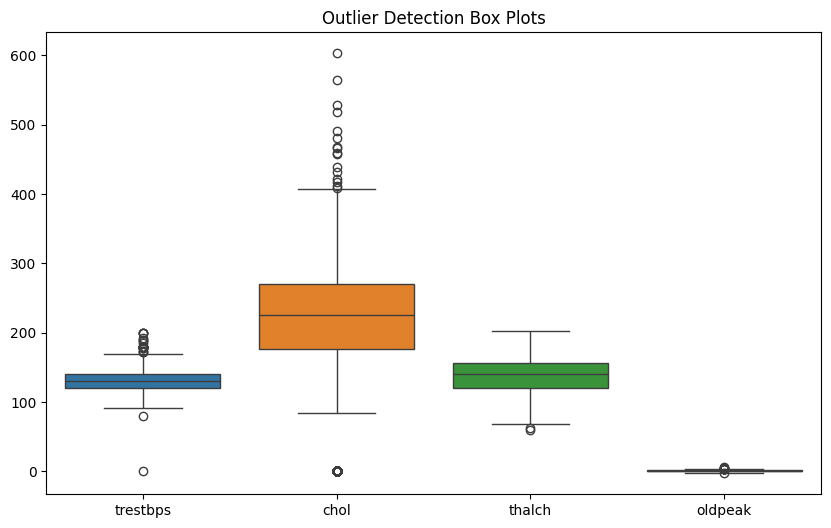

In [ ]:
# To check outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=sum[['trestbps', 'chol', 'thalch', 'oldpeak']])
plt.title('Outlier Detection Box Plots')
plt.show()

In [ ]:
# to check inconsistancy
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    print(f"--- {col} ---")
    print(sum[col].value_counts())
    print("\n")

--- sex ---
sex
Male      657
Female    189
Name: count, dtype: int64


--- cp ---
cp
asymptomatic       464
non-anginal        184
atypical angina    158
typical angina      40
Name: count, dtype: int64


--- fbs ---
fbs
False    688
True     158
Name: count, dtype: int64


--- restecg ---
restecg
normal              520
lv hypertrophy      180
st-t abnormality    146
Name: count, dtype: int64


--- exang ---
exang
False    512
True     333
FALSE      1
Name: count, dtype: int64


--- slope ---
slope
flat           425
upsloping      276
downsloping    145
Name: count, dtype: int64


--- thal ---
thal
reversable defect    334
normal               318
fixed defect         194
Name: count, dtype: int64




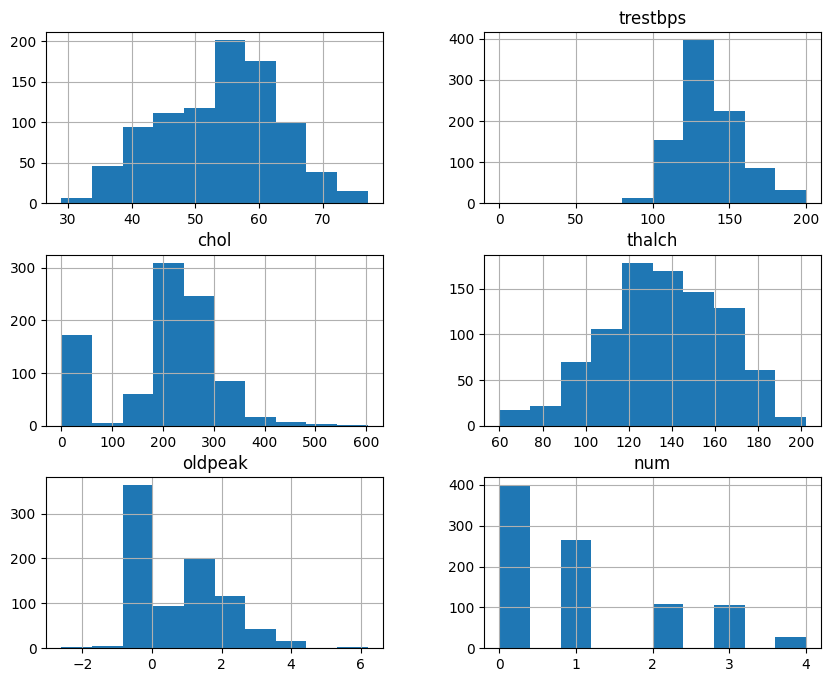

In [ ]:
df.hist(figsize = (10,8))
plt.show()

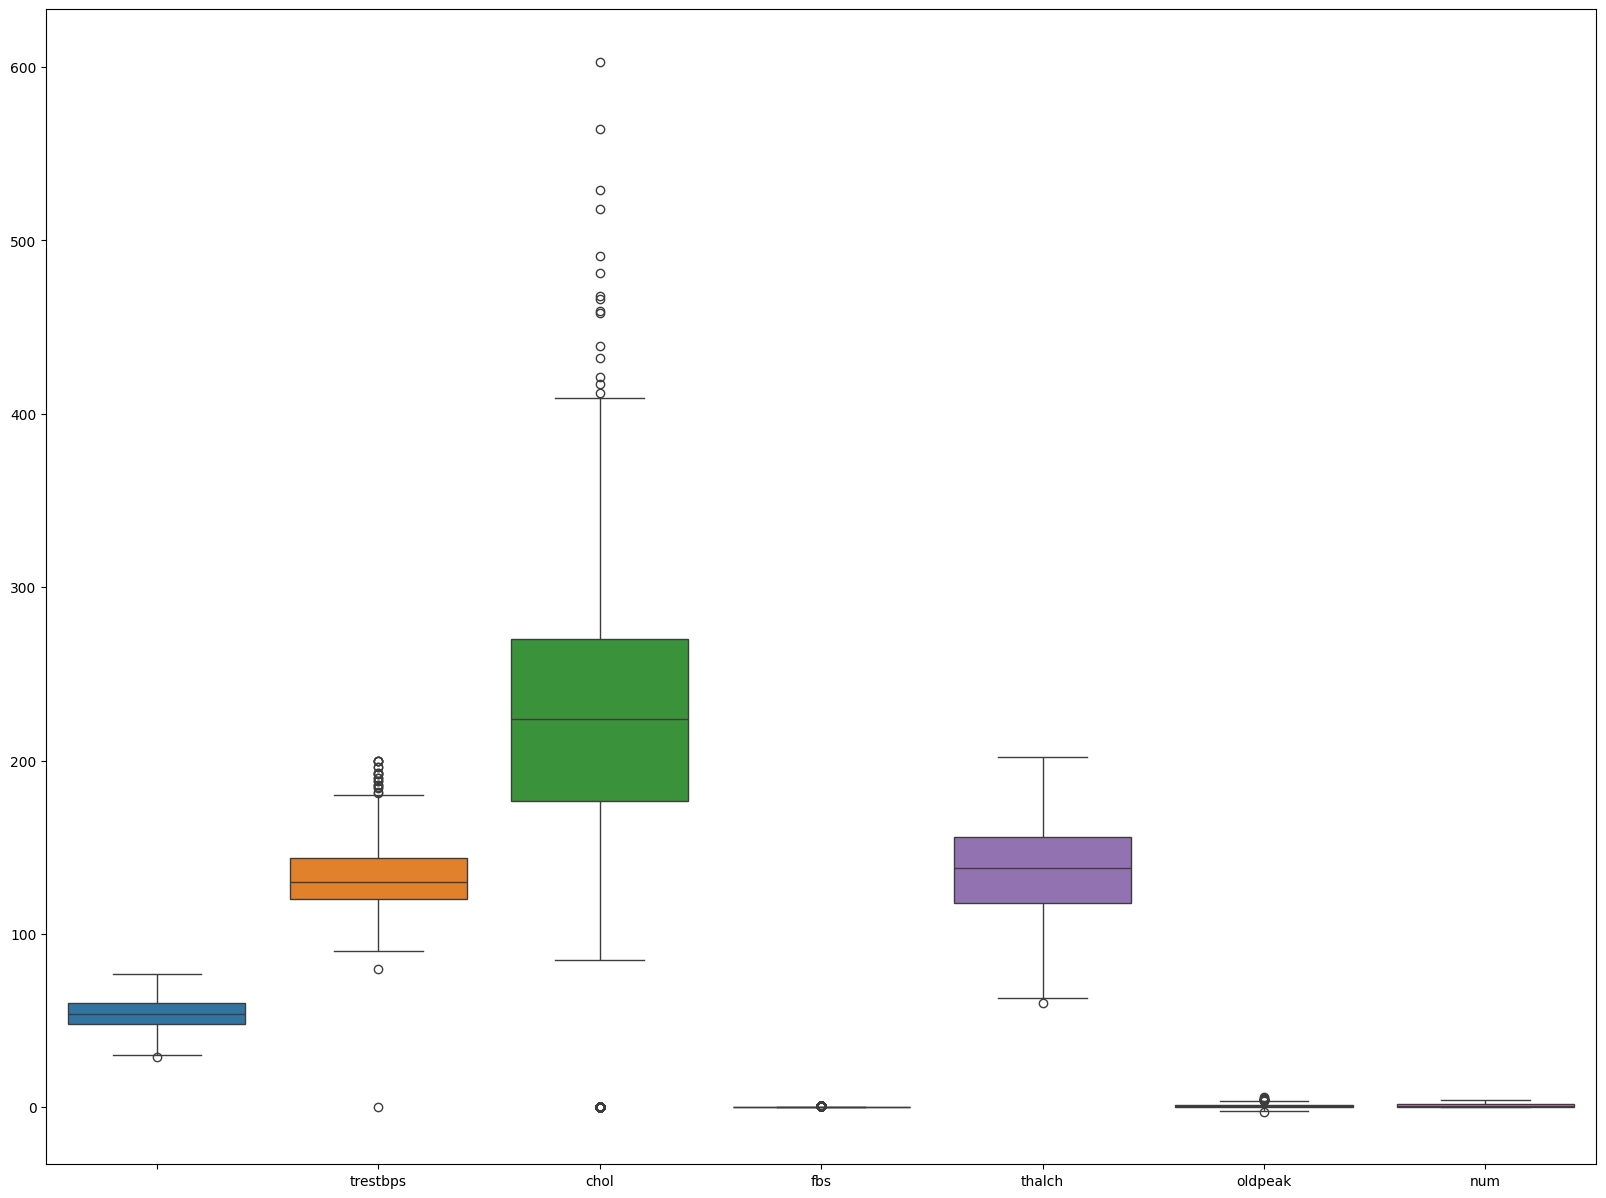

In [ ]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.xticks()
plt.show()


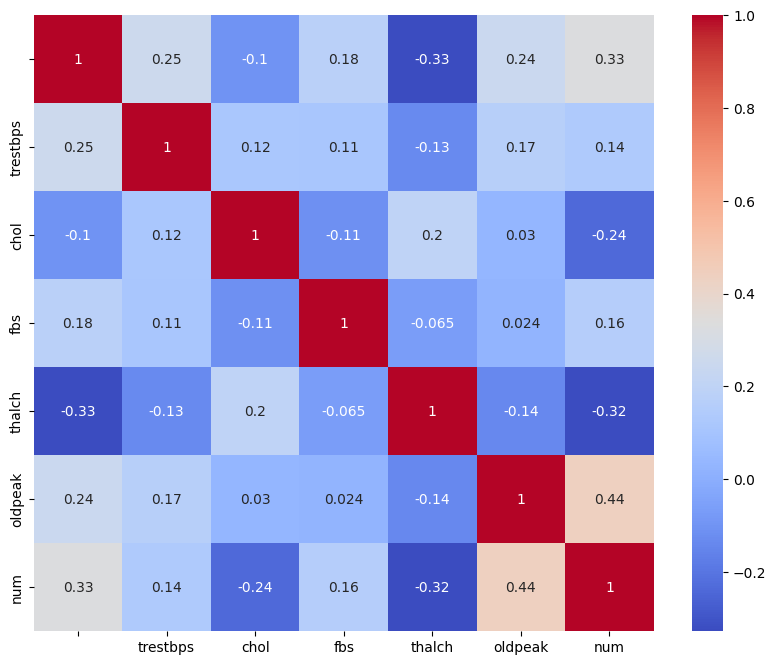

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()



In [ ]:
df['exang'] = df['exang'].replace({'FALSE': False})

sum = df.dropna()
sum_encoded = pd.get_dummies(sum, drop_first=True)
print(sum_encoded.head())

       trestbps  chol    fbs  thalch  oldpeak  num  sex_Male  \
0  63       145   233   True     150      2.3    0      True   
1  41       135   203  False     132      0.0    0      True   
2  57       140   192  False     148      0.4    0      True   
3  52       118   186  False     190      0.0    0      True   
4  57       110   201  False     126      1.5    0      True   

   cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
0               False           False               True           False   
1                True           False              False            True   
2               False           False              False            True   
3               False           False               True           False   
4               False           False              False            True   

   restecg_st-t abnormality  exang_True  slope_flat  slope_upsloping  \
0                     False       False       False            False   
1             

In [ ]:
X = sum_encoded.drop('num', axis=1)
y = sum_encoded['num']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


0.48823529411764705

In [ ]:
classification_report(y_test, y_pred)


'              precision    recall  f1-score   support\n\n           0       0.73      0.69      0.71        80\n           1       0.34      0.49      0.40        41\n           2       0.19      0.29      0.23        14\n           3       0.21      0.11      0.15        27\n           4       0.50      0.12      0.20         8\n\n    accuracy                           0.49       170\n   macro avg       0.40      0.34      0.34       170\nweighted avg       0.50      0.49      0.48       170\n'

In [ ]:
confusion_matrix(y_test, y_pred)

array([[55, 20,  3,  2,  0],
       [11, 20,  6,  4,  0],
       [ 4,  4,  4,  1,  1],
       [ 5, 12,  7,  3,  0],
       [ 0,  2,  1,  4,  1]])

In [ ]:
y_prob = model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob,multi_class='ovr')
print(roc_auc)

0.5988264133837493


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\nTuned Accuracy on Test Set:", accuracy_score(y_test, y_pred_tuned))

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.5738997821350763

Tuned Accuracy on Test Set: 0.5647058823529412


--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        80
           1       0.37      0.66      0.47        41
           2       0.14      0.07      0.10        14
           3       0.50      0.04      0.07        27
           4       0.00      0.00      0.00         8

    accuracy                           0.56       170
   macro avg       0.35      0.32      0.29       170
weighted avg       0.54      0.56      0.51       170


--- Confusion Matrix (Tuned Model) ---
[[67 13  0  0  0]
 [14 27  0  0  0]
 [ 1 12  1  0  0]
 [ 4 19  3  1  0]
 [ 2  2  3  1  0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


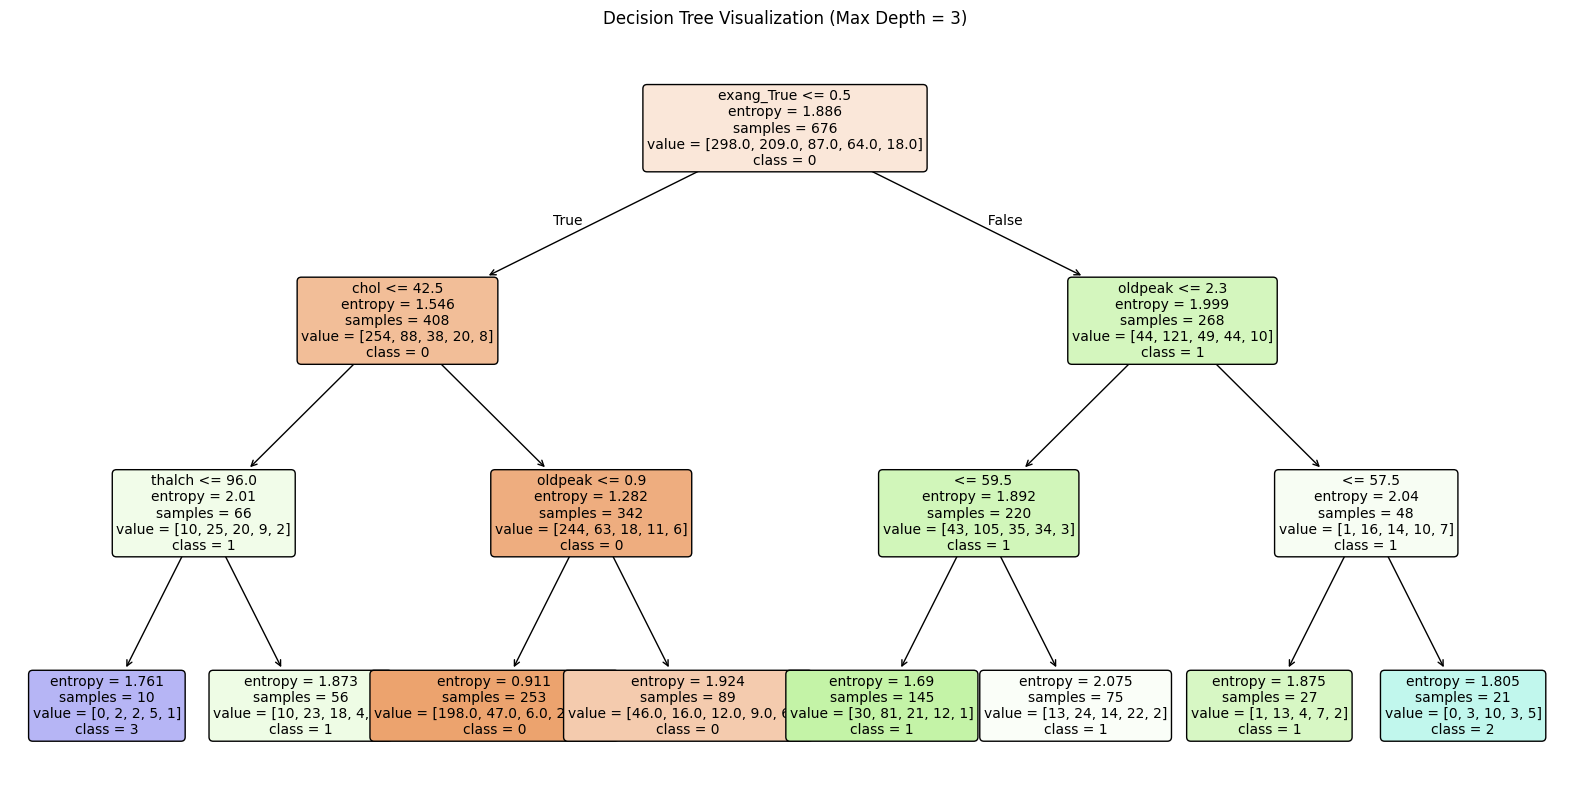

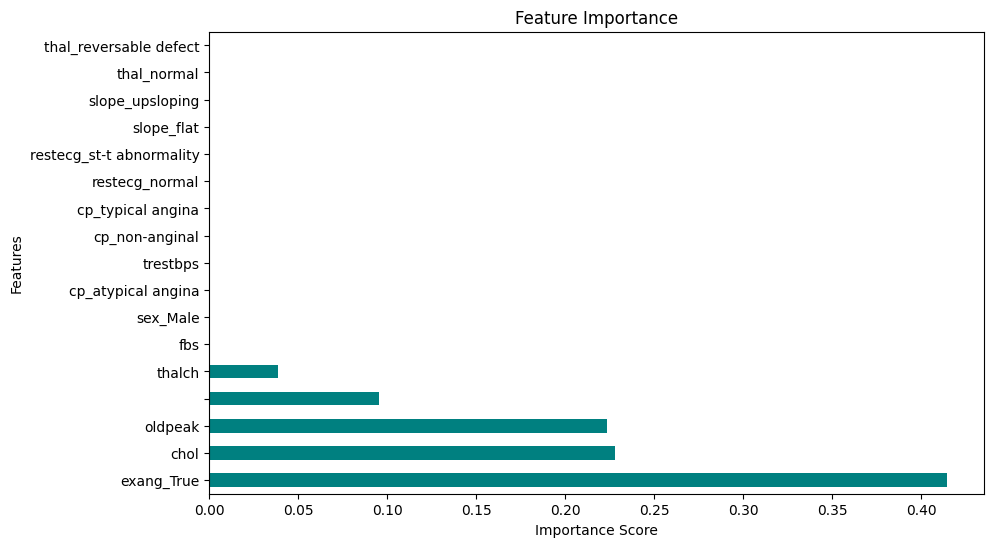

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

#Detailed Performance Metrics for the Tuned Model
print("--- Classification Report (Tuned Model) ---")
print(classification_report(y_test, y_pred_tuned))

print("\n--- Confusion Matrix (Tuned Model) ---")
print(confusion_matrix(y_test, y_pred_tuned))

# 2. Visualize the Decision Tree Structure
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (Max Depth = 3)")
plt.show()

# 3. Feature Importance Analysis
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=False).plot(kind='barh', color='teal')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
# Hyperparameter tuning raised your cross-validation accuracy to around 57.4% and test accuracy to 56.5%, improving stability compared to the default overfit tree. Because the optimal max_depth was restricted to 3, the visual tree will remain compact and easily readable, preventing the model from memorizing noise in the training set.
#The feature importance plot will highlight which clinical attributes (such as chest pain types or heart rate metrics) played the biggest role in splitting the multi-class target variable (num).

In [ ]:
#interview questions
#Interview Questions:
#max_depth: Controls the maximum depth of the tree. A higher depth allows the model to learn complex decision boundaries, which increases the risk of overfitting. A lower depth acts as regularization, forcing the model to generalize better.
#min_samples_split: Defines the minimum number of samples required to split an internal node. Higher values prevent the tree from creating splits that isolate very small subsets of data, curbing overfitting.
#min_samples_leaf: Specifies the minimum number of samples required to be at a leaf node. Ensuring a minimum leaf size prevents overly granular splits and smooths out predictions.
#criterion: Determines the function used to evaluate split quality. Gini Impurity measures the probability of a misclassification, whereas Entropy (Information Gain) measures the reduction in entropy. They often yield similar trees, though entropy can result in slightly more balanced structures.


In [ ]:
#Label Encoding: Converts categorical text values into sequential integer labels such as categories like low, medium, and high become 0, 1, and 2). This implies an ordinal relationship or mathematical hierarchy, making it ideal for ordinal variables where order matters. However, applying it to nominal variables can mislead models into treating category indices as numerically meaningful.

#One-Hot Encoding: Transforms categorical features into multiple binary columns where each category gets a boolean column (0 or 1). This prevents algorithms from assuming any false numerical ranking or distance between categories, making it standard practice for nominal data.